# Filtering XMALab Style

In [ ]:
# Source code in .h
#pragma once

#ifndef FILTERIAMGE_H
#define FILTERIAMGE_H
#include <opencv2/core/core.hpp>

# namespace xma
# {
# 	class FilterImage
# 	{
# 	public:
# 		cv::Mat run(cv::Mat & ImageIn);
# 	};
# }
# #endif // FILTERIAMGE_H




# Source Code in .cpp


# using namespace xma;

# cv::Mat FilterImage::run(cv::Mat& ImageIn)
# {
# 	int krad = Settings::getInstance()->getIntSetting("VisualFilter_krad");
# 	krad = 2 * krad + 1;
# 	float gsigma = Settings::getInstance()->getFloatSetting("VisualFilter_gsigma");
# 	float img_wt = Settings::getInstance()->getFloatSetting("VisualFilter_img_wt");
# 	float blur_wt = Settings::getInstance()->getFloatSetting("VisualFilter_blur_wt");
# 	float gamma = Settings::getInstance()->getFloatSetting("VisualFilter_gamma");
# 	// Make blur mask
# 	cv::Mat img_gblur;
# 	GaussianBlur(ImageIn, img_gblur, cv::Size(krad, krad), gsigma);

# 	// Subtract blur from original to produce sharp
# 	cv::Mat img_addwt;
# 	addWeighted(ImageIn, img_wt, img_gblur, blur_wt, 0, img_addwt);

# 	// Gamma correction to enhance contrast
# 	cv::Mat img_gamma;
# 	unsigned char lut[256];
# 	for (int i = 0; i < 256; i++)
# 	{
# 		lut[i] = cv::saturate_cast<uchar>(pow((float)(i / 255.0), gamma) * 255.0f);
# 	}

# 	img_gamma = img_addwt.clone();
# 	const int channels = img_gamma.channels();
# 	switch (channels)
# 	{
# 		case 1:
# 		{
# 			cv::MatIterator_<uchar> it, end;
# 			for (it = img_gamma.begin<uchar>(), end = img_gamma.end<uchar>(); it != end; it++)
# 				*it = lut[(*it)];
# 			break;
# 		}
# 		case 3:
# 		{
# 			cv::MatIterator_<cv::Vec3b> it, end;
# 			for (it = img_gamma.begin<cv::Vec3b>(), end = img_gamma.end< cv::Vec3b>(); it != end; it++)
# 			{
# 				(*it)[0] = lut[((*it)[0])];
# 				(*it)[1] = lut[((*it)[1])];
# 				(*it)[2] = lut[((*it)[2])];
# 			}
# 			break;
# 		}
# 	}
# 	return img_gamma;
# }


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filter_image_xmalab_style(
    image_in: np.ndarray,
    krad: int = 2,
    gsigma: float = 1.0,
    img_wt: float = 1.5,
    blur_wt: float = -0.5,
    gamma: float = 1.0,
    *,
    enforce_uint8: bool = True,
) -> np.ndarray:
    """
    Python conversion of the XMALab-style visual filter.

    Steps (same as C++):
    1) Gaussian blur
    2) Weighted subtraction/addition (sharpen-like)
    3) Gamma correction via LUT
    """
    if image_in is None:
        raise ValueError("image_in is None")

    if enforce_uint8 and image_in.dtype != np.uint8:
        image_in = np.clip(image_in, 0, 255).astype(np.uint8)

    # C++ used krad = 2 * krad + 1 to force odd kernel size.
    ksize = 2 * int(krad) + 1
    if ksize < 1:
        ksize = 1
    if ksize % 2 == 0:
        ksize += 1

    img_gblur = cv2.GaussianBlur(image_in, (ksize, ksize), float(gsigma))

    # Equivalent to addWeighted(ImageIn, img_wt, img_gblur, blur_wt, 0, img_addwt)
    img_addwt = cv2.addWeighted(image_in, float(img_wt), img_gblur, float(blur_wt), 0.0)

    # Gamma LUT: lut[i] = saturate_cast<uchar>(pow(i/255.0, gamma) * 255.0f)
    lut = np.array([
        np.clip(((i / 255.0) ** float(gamma)) * 255.0, 0, 255)
        for i in range(256)
    ], dtype=np.uint8)

    img_gamma = cv2.LUT(img_addwt, lut)
    return img_gamma




In [65]:
# Example usage:

image = cv2.imread(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\TrainingData_T42\Cam1\Cam1_Img004444.jpg", cv2.IMREAD_UNCHANGED)
filtered = filter_image_xmalab_style(image,
                                     krad=2,
                                     gsigma=1.0,
                                     img_wt=1.4,
                                     blur_wt=-0.5,
                                     gamma=1.5)

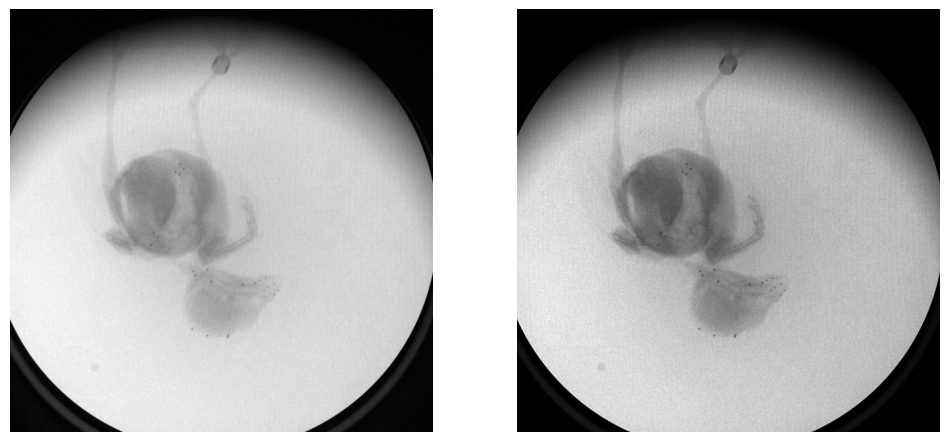

In [66]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered, cmap="gray")
plt.axis("off")
plt.show()